In [311]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons

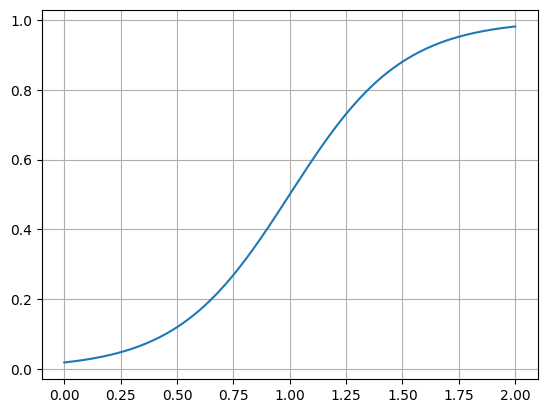

In [312]:
class subject:
    def __init__(self, scale = 0.3):
        self.scale = scale

    def psych(self, delta):
        """Underlying distribution"""
        return 1/(1 + np.exp(-(delta - 1)/self.scale))

    def query(self, delta):
        """Question: Is this side is higher than the other side"""
        """Bernoulli distribution"""
        return np.random.uniform(low=0, high=1) < self.psych(delta)

sub = subject(scale = 0.25)
x = np.linspace(0, 2, 200)
y = [sub.psych(x_) for x_ in x]

fig, ax = plt.subplots()
plt.plot(x, y, label='Underlying psychometric')
plt.grid()
plt.show()


## Naive Sampling

Pick bins from random uniform

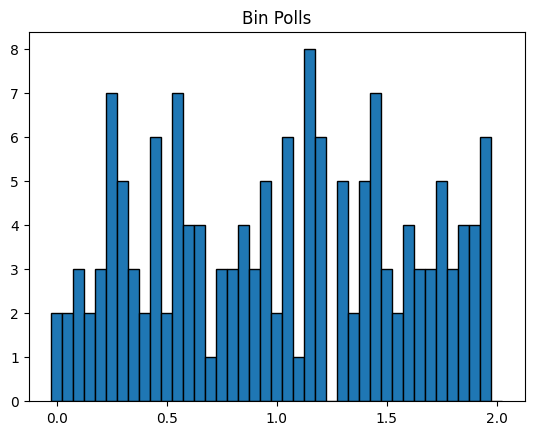

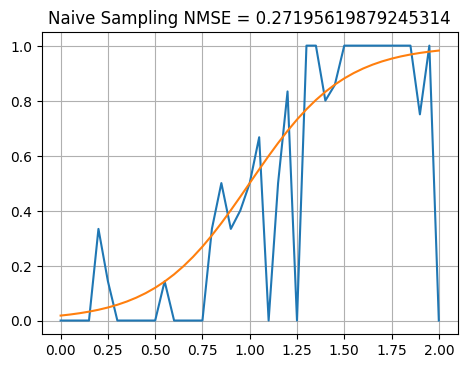

In [315]:
max_polls = 150
num_bins = 41
bins = np.linspace(0, 2, num_bins)

successes = [0] * num_bins
failures = [0] * num_bins
totals = [0] * num_bins
for _ in range(max_polls):
    ind = np.random.randint(low=0, high=41)
    bin = bins[ind]
    answer = sub.query(bin)

    if answer:
        successes[ind] += 1
    else:
        failures[ind] += 1
    totals[ind] += 1

prop_estimates = []
for s, t in zip(successes, totals):
    if t == 0:
        prop_estimates.append(0)
    else:
        prop_estimates.append(s/t)

prop_actual = [sub.psych(b) for b in bins]

plt.figure()
plt.title('Bin Polls')
plt.bar(bins, totals, width=0.05, edgecolor='black')

nmse = np.square(np.subtract(np.array(prop_estimates), np.array(prop_actual))).mean() / (np.array(prop_estimates).mean() * np.array(prop_actual).mean())

fig, ax = plt.subplots()
fig.subplots_adjust(left=0.25, bottom=0.25)
plt.title('Naive Sampling NMSE = {}'.format(nmse))
plt.plot(bins, prop_estimates, label='Estimate')
plt.plot(bins, prop_actual, label='actual')
plt.grid()
plt.show()

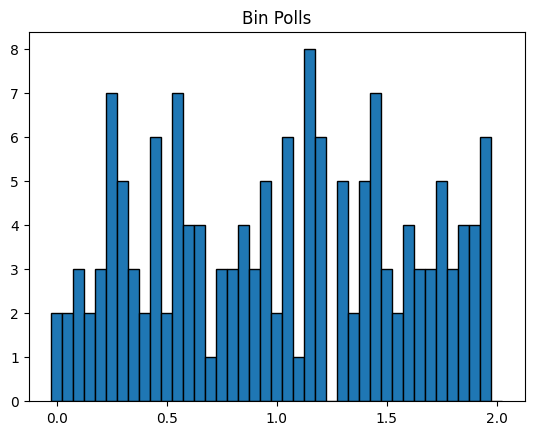

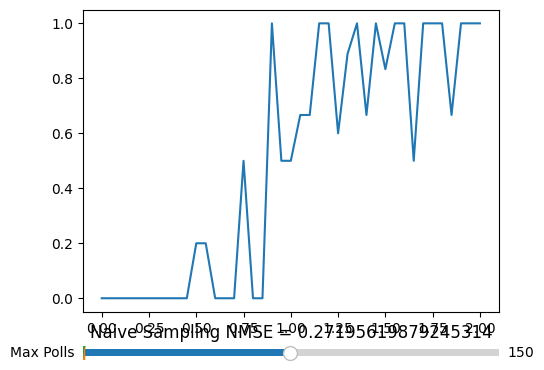

In [316]:
def simulate_naive(max_polls=150, num_bins=41):
    bins = np.linspace(0, 2, num_bins)

    successes = [0] * num_bins
    failures = [0] * num_bins
    totals = [0] * num_bins
    for _ in range(max_polls):
        ind = np.random.randint(low=0, high=41)
        bin = bins[ind]
        answer = sub.query(bin)

        if answer:
            successes[ind] += 1
        else:
            failures[ind] += 1
        totals[ind] += 1

    prop_estimates = []
    for s, t in zip(successes, totals):
        if t == 0:
            prop_estimates.append(0)
        else:
            prop_estimates.append(s/t)

    return prop_estimates

prop_actual = [sub.psych(b) for b in bins]

plt.figure()
plt.title('Bin Polls')
plt.bar(bins, totals, width=0.05, edgecolor='black')

nmse = np.square(np.subtract(np.array(prop_estimates), np.array(prop_actual))).mean() / (np.array(prop_estimates).mean() * np.array(prop_actual).mean())

fig, ax = plt.subplots()
fig.subplots_adjust(left=0.25, bottom=0.25)


[line] = ax.plot(bins, simulate_naive(max_polls, num_bins))

max_polls_slider_ax = fig.add_axes([0.25, 0.15, 0.65, 0.03])
max_polls_slider = Slider(max_polls_slider_ax, 'Max Polls', 1, 300, valinit=150)

num_bins_slider_ax = fig.add_axes([0.25, 0.1, 0.65, 0.03])
num_bins_slider = Slider(num_bins_slider_ax, '# Bins', 1, 100)

def sliders_on_changed(val):
    line.set_ydata(simulate_naive(max_polls_slider.val, num_bins_slider.val))
    fig.canvas.draw_idle()

max_polls_slider.on_changed(sliders_on_changed)
num_bins_slider.on_changed(sliders_on_changed)

plt.title('Naive Sampling NMSE = {}'.format(nmse))
plt.grid()
plt.show()

## Thompson Sampling
Pick bin with highest expected return

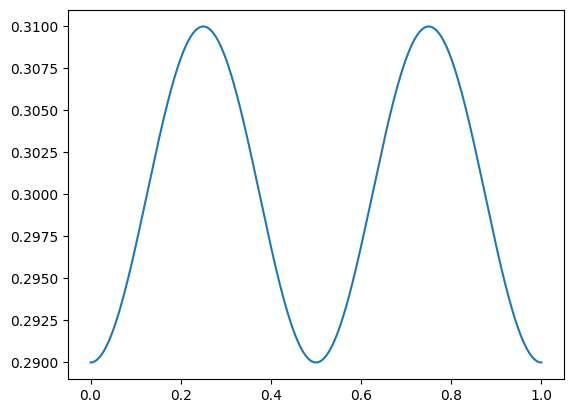

In [ ]:
def score(x):
    return 0.01 * np.cos(4*np.pi*x - np.pi) + 0.3

p = 0.5
x = np.linspace(0, 1, 1000)
y = [score(x_) for x_ in x]

plt.figure()
plt.plot(x, y, label='Score function for JND sampling')
plt.show()

[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 3, 1, 1, 2, 0, 2, 1, 3, 0, 2, 4, 5, 0, 3, 3, 6, 2, 3, 3, 2, 4, 1, 1, 1, 6, 2, 3, 3, 2]
[3, 6, 3, 5, 3, 2, 6, 2, 4, 3, 3, 4, 4, 2, 3, 3, 1, 0, 1, 3, 3, 2, 2, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0]
[3, 6, 3, 5, 3, 2, 6, 2, 4, 3, 5, 4, 7, 3, 4, 5, 1, 2, 2, 6, 3, 4, 6, 6, 2, 4, 3, 8, 3, 3, 3, 3, 5, 1, 1, 2, 6, 2, 4, 3, 2]


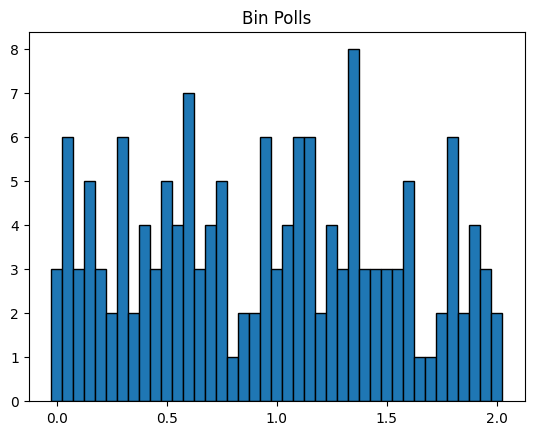

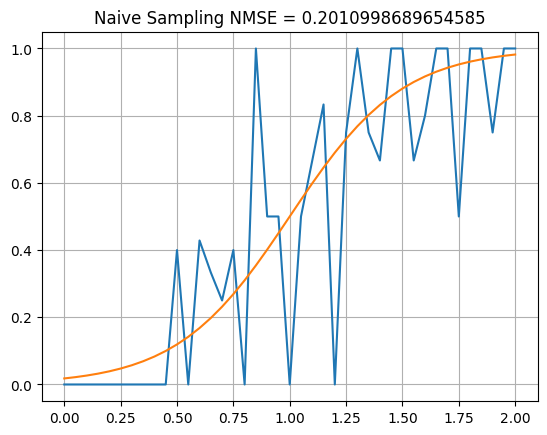

In [ ]:
successes_thompson = [0] * num_bins
failures_thompson = [0] * num_bins
totals_thompson = [0] * num_bins

for _ in range(max_polls):
    samples = [np.random.beta(s+1, f+1) for s, f in zip(successes_thompson, failures_thompson)]

    scores = [score(s) for s in samples]

    ind = np.argmax(scores)
    bin = bins[ind]
    answer = s.query(bin)

    if answer:
        successes_thompson[ind] += 1
    else:
        failures_thompson[ind] += 1
    totals_thompson[ind] += 1

print(bins)
print(successes_thompson)
print(failures_thompson)
print(totals_thompson)
plt.figure()
plt.title('Bin Polls')
plt.bar(bins, totals_thompson, width=0.05, edgecolor='black')

prop_estimates_thompson = [s/t for s, t in zip(successes_thompson, totals_thompson)]

nmse = np.square(np.subtract(np.array(prop_estimates_thompson), np.array(prop_actual))).mean() / (np.array(prop_estimates_thompson).mean() * np.array(prop_actual).mean())

fig, ax = plt.subplots()
plt.title('Naive Sampling NMSE = {}'.format(nmse))
plt.plot(bins, prop_estimates_thompson, label='Estimate')
plt.plot(bins, prop_actual, label='actual')
plt.grid()
plt.show()